In [10]:
import pandas as pd
import numpy as np
import datetime as dt

In [11]:
# Battery configuration used across all months
P_MAX = 1       # Battery can charge/discharge 1 MW each hour
E_MAX = 2       # Battery can store up to 2 MWh (2 hours)
RTE = 0.85      # 85% round-trip efficiency
HUB = "HB_HOUSTON"   # which ERCOT hub to use

In [12]:
def tau_greedy_day(prices):

    # Runs the τ-greedy algorithm for one day's price array.
    # For each possible τ (1..23), the battery:
    # - Can ONLY charge before τ
    # - Can ONLY discharge after τ
    # The algorithm picks the cheapest charge hours and most expensive discharge hours.
    # Returns:
    #     best_rev: maximum revenue for that day
    #     best_tau: τ that achieved that revenue

    prices = np.array(prices)
    best_rev = 0
    best_tau = None

    for tau in range(1, 24):

        # Buy hours: before τ
        buy_hours  = np.arange(0, tau)

        # Sell hours: after τ
        sell_hours = np.arange(tau, 24)

        # Cheapest buy hours, highest-priced sell hours
        buy_sorted  = buy_hours[np.argsort(prices[buy_hours])]
        sell_sorted = sell_hours[np.argsort(-prices[sell_hours])]

        energy_used = 0
        revenue = 0

        # Match cheap buys with expensive sells
        for b, s in zip(buy_sorted, sell_sorted):

            if energy_used >= E_MAX:
                break

            spread = prices[s] * RTE - prices[b]
            if spread <= 0:
                break

            revenue += spread
            energy_used += 1

        # Keep track of best τ
        if revenue > best_rev:
            best_rev = revenue
            best_tau = tau

    return best_rev, best_tau


In [13]:
def load_and_clean_month(excel_path, sheet_name, hub=HUB):

    # Loads one month of ERCOT DAM prices and prepares clean 24-hour price arrays.
    # Skips any days that do not contain exactly 24 hourly prices.
 
    df = pd.read_excel(excel_path, sheet_name=sheet_name)
    df = df[df['Settlement Point'] == hub]

    df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])
    df['hour'] = df['Hour Ending'].str.split(':').str[0].astype(int)
    df['timestamp'] = df['Delivery Date'] + pd.to_timedelta(df['hour'], unit='h')

    df = df[['timestamp', 'Settlement Point Price']]
    df = df.rename(columns={'Settlement Point Price': 'price'})
    df = df.reset_index()

    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour

    mask = (df['hour'] == 0) & (df['index'] > 0)
    df.loc[mask, 'hour'] = 24
    df.loc[mask, 'date'] = df['date'].shift(1)

    days = sorted(df['date'].unique())
    daily_arrays = []
    clean_days = []

    for d in days:
        day_df = df[df['date'] == d].sort_values('hour')
        prices = day_df['price'].values

        if len(prices) != 24:
            print(f"Skipping {d}: {len(prices)} hours found")
            continue

        daily_arrays.append(prices)
        clean_days.append(d)

    return clean_days, daily_arrays


In [14]:
def process_month(sheet_name, excel_path, hub=HUB):

    # Runs τ-greedy on all days of one month.
    # Returns a DataFrame with:
    #     date
    #     revenue
    #     tau
    #     month

    days, daily_arrays = load_and_clean_month(excel_path, sheet_name, hub)

    results = []
    for i, arr in enumerate(daily_arrays):
        rev, tau = tau_greedy_day(arr)
        results.append({
            'date': days[i],
            'revenue': rev,
            'tau': tau,
            'month': sheet_name
        })

    return pd.DataFrame(results)

In [15]:
def run_all_months(excel_path, hub=HUB):

    # Loops through Jan–Oct and processes all months automatically.
    # Returns a single combined DataFrame.

    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct"]

    all_results = []

    for m in months:
        print(f"Processing {m}...")
        monthly_df = process_month(m, excel_path, hub)
        all_results.append(monthly_df)

    full_df = pd.concat(all_results).reset_index(drop=True)
    return full_df


In [ ]:
excel_path = "C:\Users\shynmere\Desktop\ERCOT BESS Index\dam25.xlsx"


full_year_df = run_all_months(excel_path)

full_year_df


Processing Jan...
Processing Feb...
Processing Mar...
Skipping 2025-03-09: 23 hours found
Processing Apr...
Processing May...
Processing Jun...
Processing Jul...
Processing Aug...
Processing Sep...
Processing Oct...


,date,revenue,tau,month
0,2025-01-01,30.0780,16,Jan
1,2025-01-02,28.0710,4,Jan
2,2025-01-03,20.9065,16,Jan
3,2025-01-04,14.7855,14,Jan
4,2025-01-05,39.0105,4,Jan
...,...,...,...,...
298,2025-10-27,117.1920,12,Oct
299,2025-10-28,56.4185,11,Oct
300,2025-10-29,64.4610,16,Oct
301,2025-10-30,91.0735,16,Oct


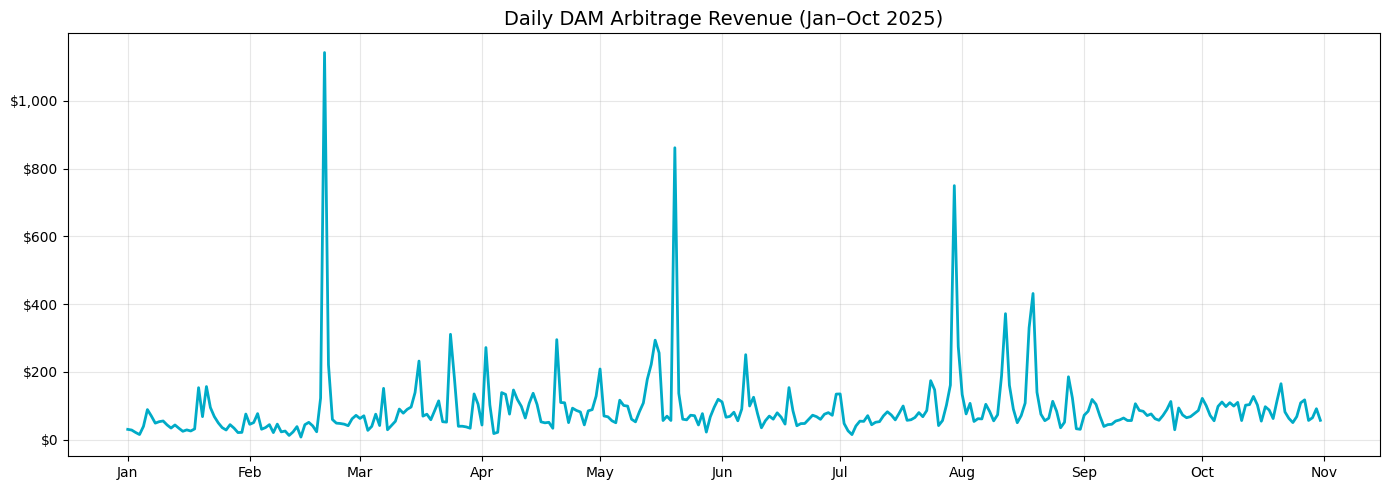

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(14,5))

plt.plot(full_year_df['date'], full_year_df['revenue'], 
         color="#00ABC7", linewidth=2)

# Format x-axis: monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Dollar formatting on y-axis
fmt = FuncFormatter(lambda x, pos: f'${x:,.0f}')
plt.gca().yaxis.set_major_formatter(fmt)

plt.title("Daily DAM Arbitrage Revenue (Jan–Oct 2025)", fontsize=14)
plt.ylabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\shynmere\AppData\Local\Temp\ipykernel_2436\637069667.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = full_year_df.groupby('month')['revenue'].mean()


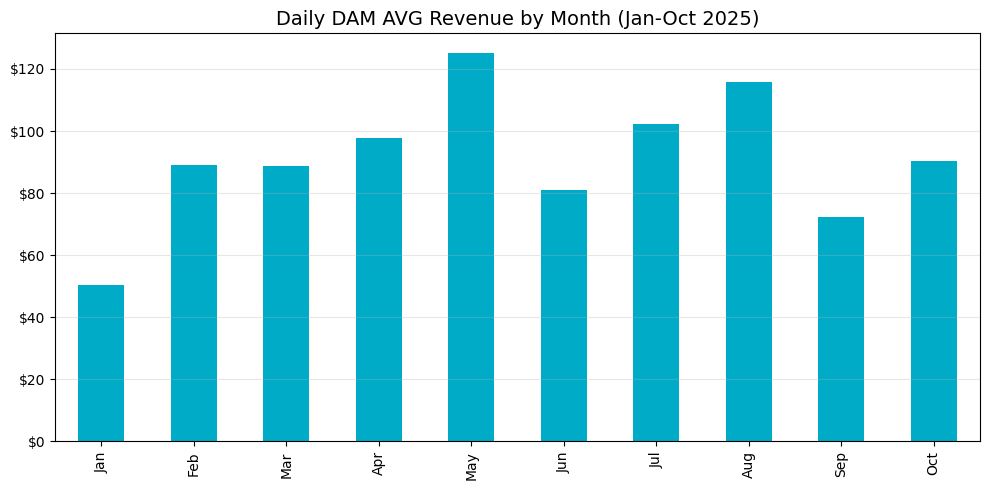

In [18]:
from matplotlib.ticker import FuncFormatter

# Fix month ordering
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct"]

full_year_df['month'] = pd.Categorical(full_year_df['month'], 
                                       categories=month_order,
                                       ordered=True)

# Compute monthly averages
monthly_avg = full_year_df.groupby('month')['revenue'].mean()

# Plot
plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color="#00ABC7")

plt.ylabel("")
plt.xlabel("")
plt.title("Daily DAM AVG Revenue by Month (Jan-Oct 2025)", fontsize=14)

# Dollar formatting
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
